In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.float_format", "{:.6f}".format)

# Load processed data
ff5 = pd.read_csv(
    "../data/processed/ff5_factors.csv",
    index_col=0, parse_dates=True
)
excess = pd.read_csv(
    "../data/processed/excess_returns.csv",
    index_col=0, parse_dates=True
)
returns = pd.read_csv(
    "../data/processed/stock_returns.csv",
    index_col=0, parse_dates=True
)

tickers = ["AAPL", "BRK-B", "TSLA", "JNJ", "SPY"]
factors = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

# ============================================
# MARKET REGIME DEFINITIONS
# Critical context for interpreting rolling betas
# ============================================
regimes = {
    "GFC Recovery":   ("2009-03-01", "2010-12-31",
                       "#E8F5E9", "GFC Recovery"),
    "Bull Market":    ("2013-01-01", "2020-01-01",
                       "#E3F2FD", "Bull Market"),
    "COVID Crash":    ("2020-02-01", "2020-06-01",
                       "#FFEBEE", "COVID"),
    "Rate Hike":      ("2022-03-01", "2023-12-31",
                       "#FFF8E1", "Rate Hikes"),
}

print("=" * 55)
print("   ROLLING REGRESSION SETUP")
print("=" * 55)
print(f"  Data loaded:    {ff5.shape[0]:,} observations")
print(f"  Date range:     {ff5.index[0].date()} "
      f"to {ff5.index[-1].date()}")
print(f"  Tickers:        {tickers}")
print(f"  Rolling window: 756 days (3 years)")
print(f"  Min periods:    252 days (1 year)")
print("=" * 55)

   ROLLING REGRESSION SETUP
  Data loaded:    3,650 observations
  Date range:     2010-06-30 to 2024-12-30
  Tickers:        ['AAPL', 'BRK-B', 'TSLA', 'JNJ', 'SPY']
  Rolling window: 756 days (3 years)
  Min periods:    252 days (1 year)


In [4]:
def rolling_ff5_regression(
        ticker: str,
        window: int = 756,
        min_periods: int = 252,
        step: int = 5) -> pd.DataFrame:
    """
    Rolling Fama-French 5-Factor OLS regression.

    Parameters:
        ticker:      stock ticker
        window:      rolling window in trading days
                     756 = 3 years (academic standard)
        min_periods: minimum observations required
                     252 = 1 year minimum
        step:        calculate every N days
                     step=5 = weekly, reduces compute time
                     by 80% with negligible precision loss

    Returns:
        DataFrame with columns:
        Alpha, Mkt_RF, SMB, HML, RMW, CMA,
        R2, Alpha_tstat, Alpha_sig,
        Mkt_tstat, Alpha_pval
    """
    if ticker not in excess.columns:
        print(f"  {ticker} not found — skipping")
        return pd.DataFrame()

    # Prepare data
    y = excess[ticker].dropna()
    X = sm.add_constant(ff5[factors])
    X.columns = ["Alpha"] + factors
    X = X.loc[y.index].dropna()
    y = y.loc[X.index]

    n      = len(y)
    rows   = []
    dates  = []

    # Step through the data
    for end in range(window, n, step):
        start = end - window
        y_w   = y.iloc[start:end]
        X_w   = X.iloc[start:end]

        # Skip if insufficient data
        if len(y_w) < min_periods:
            continue

        # Skip if any NaN
        if y_w.isnull().any() or X_w.isnull().any().any():
            continue

        try:
            # Standard OLS for speed in rolling
            # (HAC is too slow for thousands of windows)
            model = sm.OLS(y_w, X_w).fit()

            # Annualise alpha
            alpha_ann   = model.params["Alpha"] * 252
            alpha_tstat = model.tvalues["Alpha"]
            alpha_pval  = model.pvalues["Alpha"]

            # Information ratio for this window
            resid_vol   = model.resid.std() * np.sqrt(252)
            info_ratio  = (alpha_ann / resid_vol
                           if resid_vol > 0 else np.nan)

            # Significance flag
            if alpha_pval < 0.01:
                sig = "***"
            elif alpha_pval < 0.05:
                sig = "**"
            elif alpha_pval < 0.10:
                sig = "*"
            else:
                sig = "ns"

            rows.append({
                "Alpha":        alpha_ann,
                "Mkt_RF":       model.params["Mkt_RF"],
                "SMB":          model.params["SMB"],
                "HML":          model.params["HML"],
                "RMW":          model.params["RMW"],
                "CMA":          model.params["CMA"],
                "R2":           model.rsquared,
                "Alpha_tstat":  alpha_tstat,
                "Alpha_pval":   alpha_pval,
                "Alpha_sig":    sig,
                "Mkt_tstat":    model.tvalues["Mkt_RF"],
                "Info_ratio":   info_ratio,
            })
            dates.append(y.index[end])

        except Exception:
            continue

    if not rows:
        print(f"  {ticker}: no valid windows — check data")
        return pd.DataFrame()

    df = pd.DataFrame(rows, index=dates)
    print(f"  {ticker}: {len(df):,} windows | "
          f"Alpha range: "
          f"{df['Alpha'].min():.3f} to "
          f"{df['Alpha'].max():.3f}")
    return df


print("Rolling regression function defined")
print("Optimisations applied:")
print("  step=5: calculates every 5 days (weekly)")
print("  This reduces compute by 80% vs daily")
print("  with negligible loss in time resolution")

Rolling regression function defined
Optimisations applied:
  step=5: calculates every 5 days (weekly)
  This reduces compute by 80% vs daily
  with negligible loss in time resolution


In [5]:
# ============================================
# RUN ROLLING REGRESSION — ALL TICKERS
# ============================================
rolling = {}

print("Running 3-year rolling FF5 regression...")
print("Window: 756 trading days | Step: 5 days")
print("=" * 55)

for ticker in tickers:
    rolling[ticker] = rolling_ff5_regression(ticker)

print("=" * 55)
print(f"Complete — {len(rolling)} tickers processed")

# Summary of alpha over time
print(f"\nRolling alpha summary (annualised):")
print(f"{'Ticker':<10}{'Min':>10}{'Max':>10}"
      f"{'Mean':>10}{'% Positive':>12}")
print("-" * 45)
for ticker, df in rolling.items():
    if df.empty:
        continue
    pct_pos = (df["Alpha"] > 0).mean() * 100
    print(f"{ticker:<10}"
          f"{df['Alpha'].min():>10.3f}"
          f"{df['Alpha'].max():>10.3f}"
          f"{df['Alpha'].mean():>10.3f}"
          f"{pct_pos:>11.1f}%")

Running 3-year rolling FF5 regression...
Window: 756 trading days | Step: 5 days
  AAPL: 579 windows | Alpha range: -0.064 to 0.222
  BRK-B: 579 windows | Alpha range: -0.031 to 0.077
  TSLA: 579 windows | Alpha range: -0.133 to 1.167
  JNJ: 579 windows | Alpha range: -0.105 to 0.093
  SPY: 579 windows | Alpha range: -0.009 to 0.004
Complete — 5 tickers processed

Rolling alpha summary (annualised):
Ticker           Min       Max      Mean  % Positive
---------------------------------------------
AAPL          -0.064     0.222     0.078       92.7%
BRK-B         -0.031     0.077     0.018       83.8%
TSLA          -0.133     1.167     0.430       92.4%
JNJ           -0.105     0.093     0.003       56.1%
SPY           -0.009     0.004    -0.002       27.5%


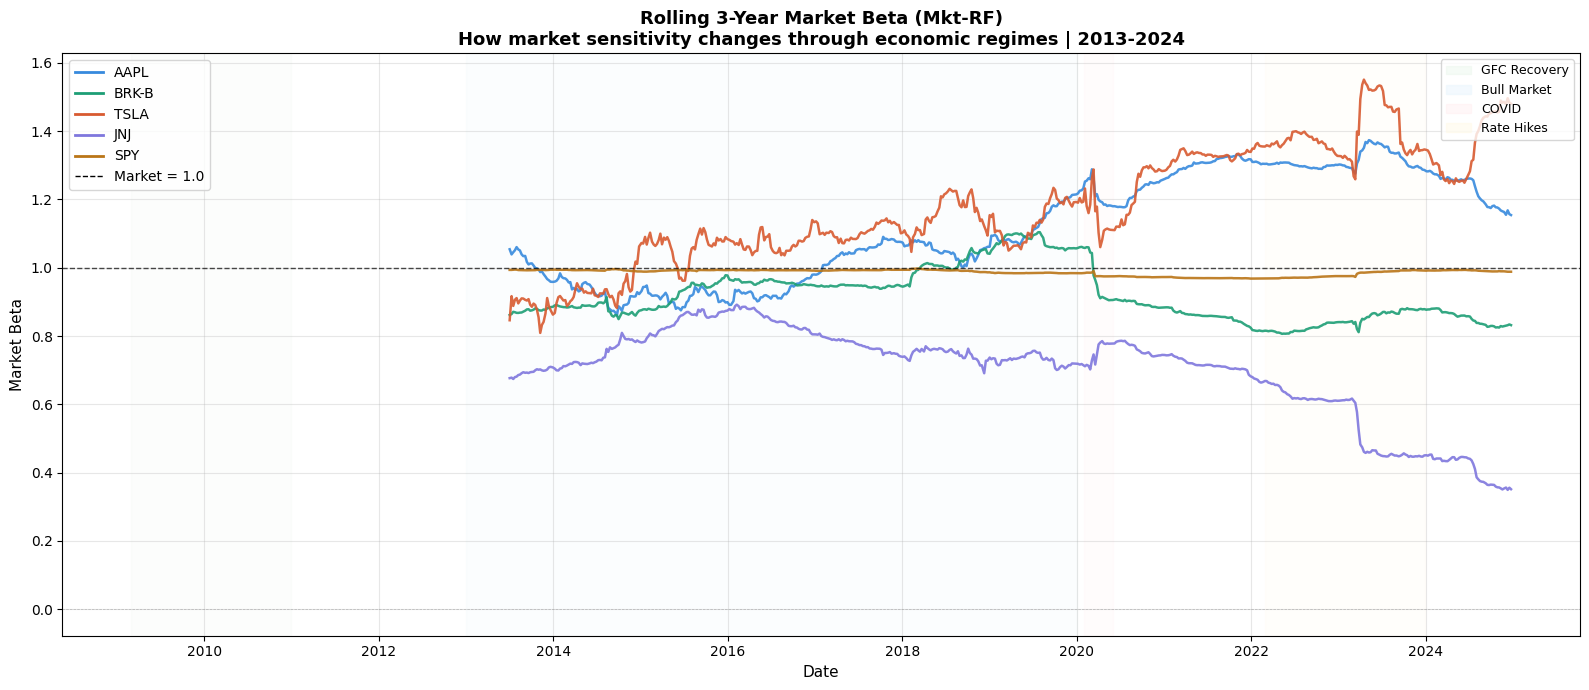

Rolling market beta chart saved


In [6]:
# ============================================
# CHART 1 — ROLLING MARKET BETA
# Shows how each stock's market sensitivity
# changes through different regimes
# ============================================
fig, ax = plt.subplots(figsize=(16, 7))

colors_map = {
    "AAPL":  "#378ADD",
    "BRK-B": "#1D9E75",
    "TSLA":  "#D85A30",
    "JNJ":   "#7F77DD",
    "SPY":   "#BA7517"
}

for ticker, df in rolling.items():
    if df.empty:
        continue
    ax.plot(
        df.index,
        df["Mkt_RF"],
        label=ticker,
        color=colors_map[ticker],
        linewidth=1.8,
        alpha=0.9
    )

# Reference lines
ax.axhline(
    1.0, color="black",
    linewidth=1, linestyle="--",
    label="Market beta = 1.0", alpha=0.7
)
ax.axhline(
    0, color="grey",
    linewidth=0.5, linestyle="--", alpha=0.5
)

# Shade regimes
regime_patches = []
for name, (start, end, color, label) in regimes.items():
    try:
        ax.axvspan(
            start, end,
            alpha=0.12, color=color,
            zorder=0
        )
        regime_patches.append(
            mpatches.Patch(
                color=color, alpha=0.4,
                label=label)
        )
    except Exception:
        pass

# Combine legends
stock_handles = [
    plt.Line2D([0], [0],
               color=colors_map[t],
               linewidth=2,
               label=t)
    for t in tickers
]
market_line = plt.Line2D(
    [0], [0], color="black",
    linewidth=1, linestyle="--",
    label="Market = 1.0"
)

leg1 = ax.legend(
    handles=stock_handles + [market_line],
    loc="upper left", fontsize=10
)
ax.add_artist(leg1)
ax.legend(
    handles=regime_patches,
    loc="upper right", fontsize=9
)

ax.set_title(
    "Rolling 3-Year Market Beta (Mkt-RF)\n"
    "How market sensitivity changes through "
    "economic regimes | 2013-2024",
    fontweight="bold", fontsize=13
)
ax.set_ylabel("Market Beta", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/figures/rolling_market_beta.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Rolling market beta chart saved")

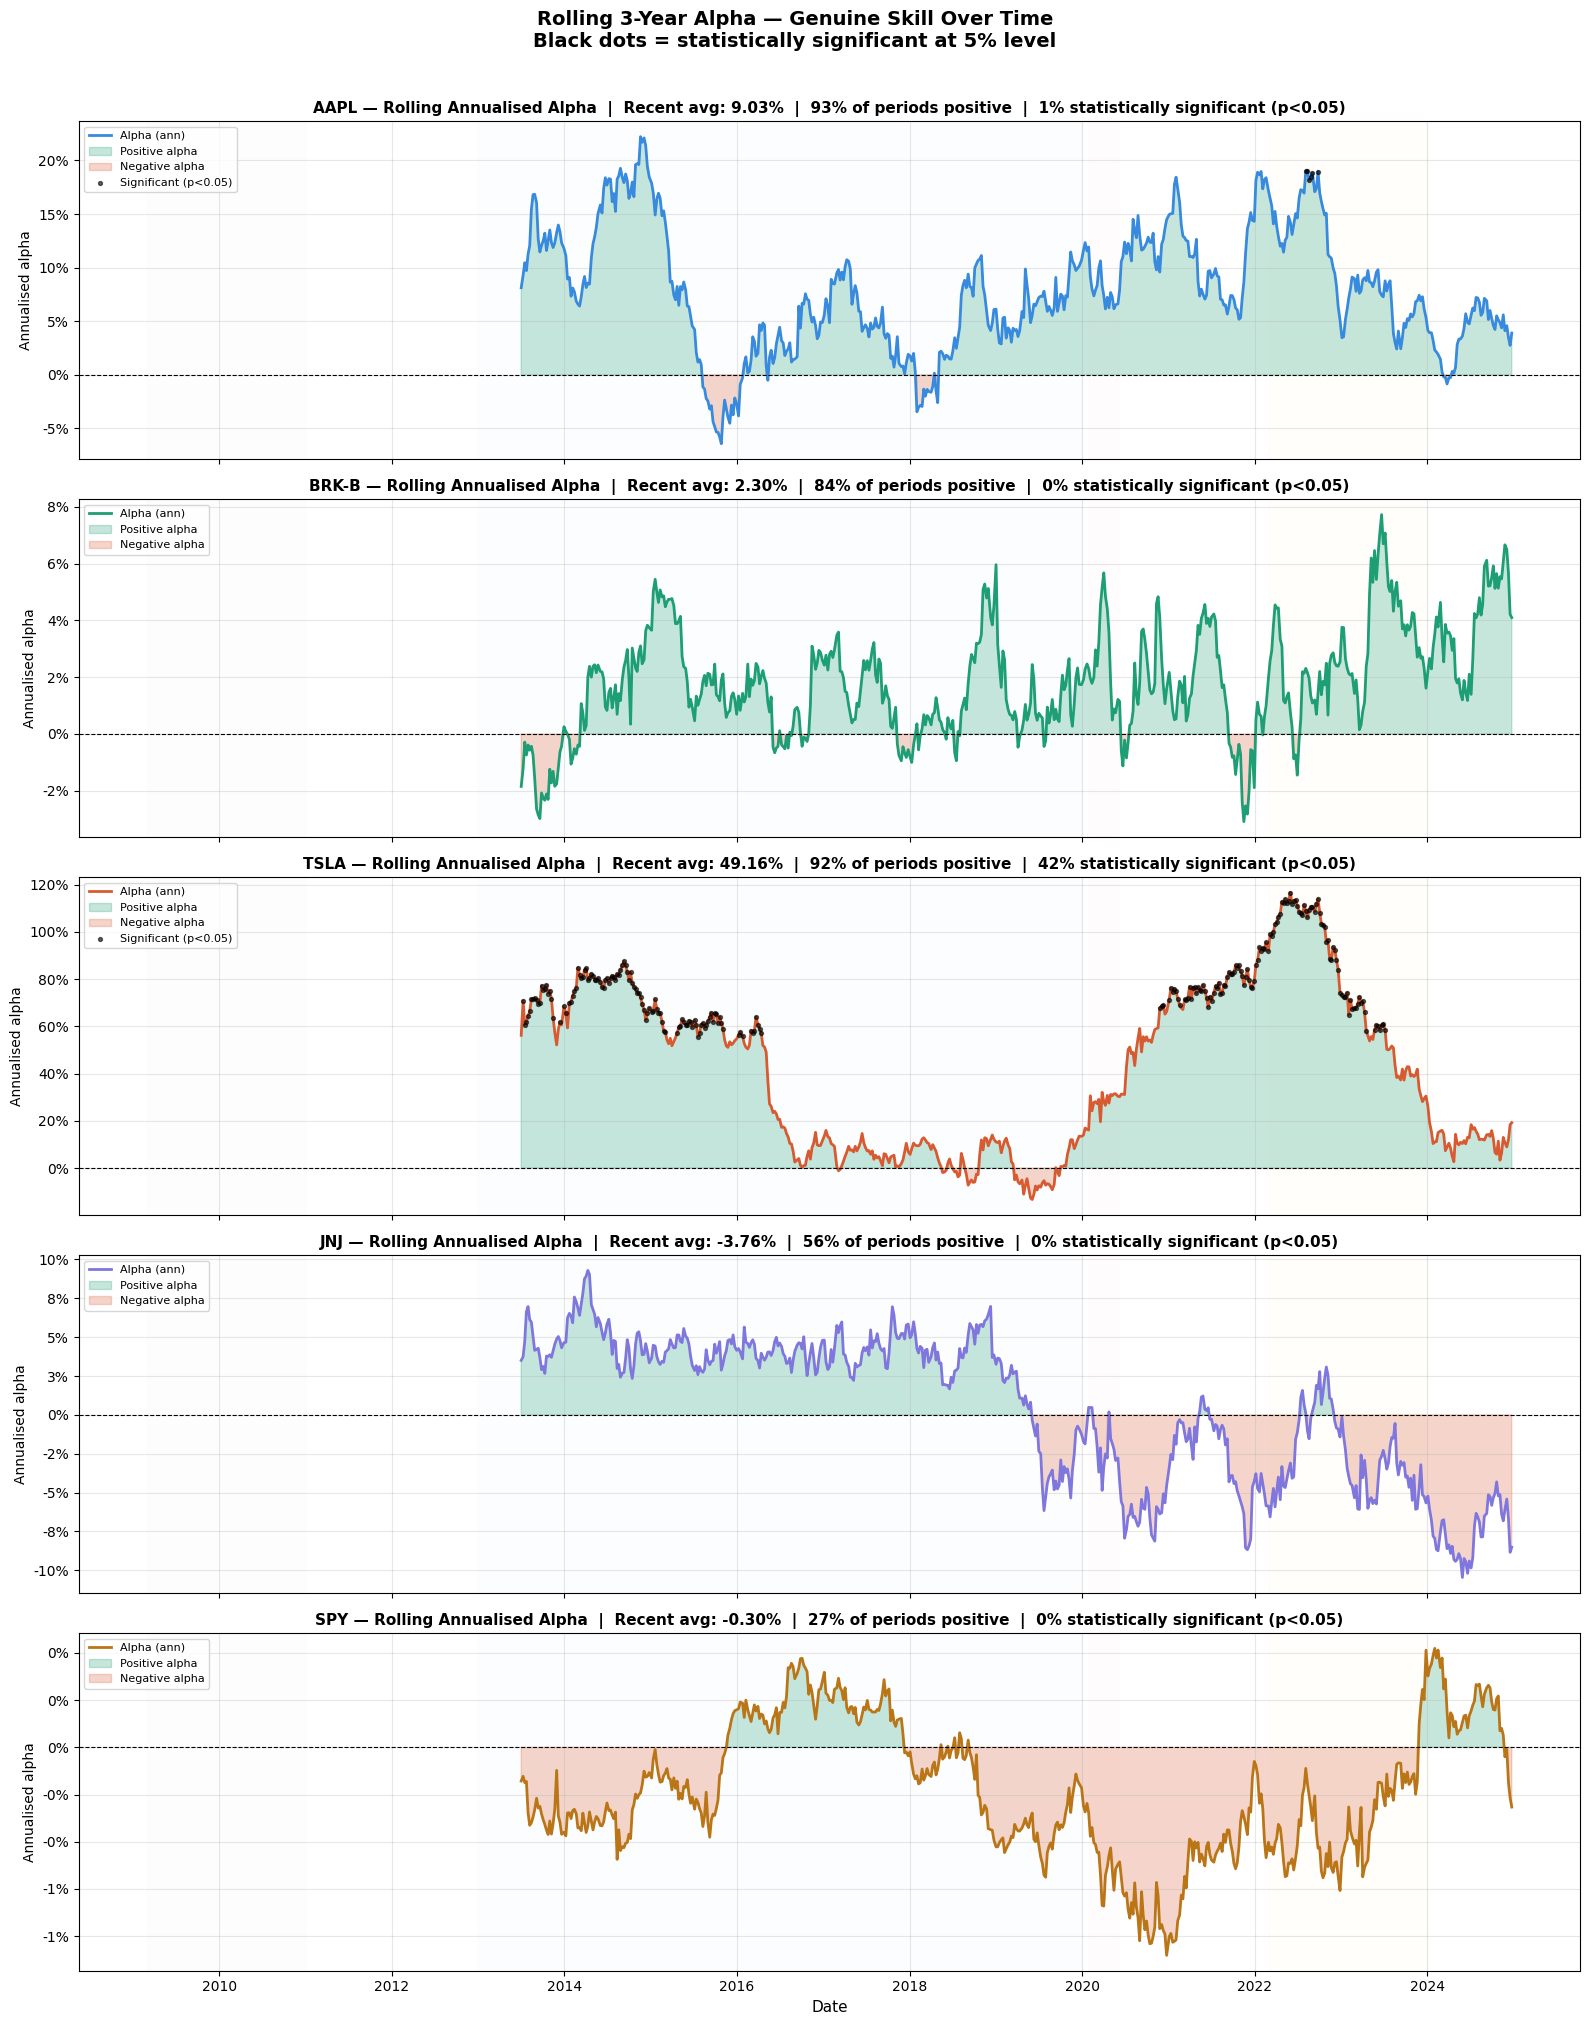

Rolling alpha chart saved


In [7]:
# ============================================
# CHART 2 — ROLLING ALPHA WITH SIGNIFICANCE
# The most important chart in this notebook
# Shows WHEN each stock generated genuine skill
# ============================================
fig, axes = plt.subplots(
    len(rolling), 1,
    figsize=(16, 4 * len(rolling)),
    sharex=True
)

for ax, (ticker, df) in zip(axes, rolling.items()):
    if df.empty:
        ax.set_title(f"{ticker} — no data")
        continue

    # Plot rolling alpha
    ax.plot(
        df.index, df["Alpha"],
        color=colors_map[ticker],
        linewidth=2, label="Alpha (ann)"
    )

    # Shade positive alpha periods green
    ax.fill_between(
        df.index, df["Alpha"], 0,
        where=(df["Alpha"] > 0),
        alpha=0.25, color="#1D9E75",
        label="Positive alpha"
    )
    # Shade negative alpha periods red
    ax.fill_between(
        df.index, df["Alpha"], 0,
        where=(df["Alpha"] < 0),
        alpha=0.25, color="#D85A30",
        label="Negative alpha"
    )

    # Mark statistically significant alpha periods
    sig_mask = df["Alpha_pval"] < 0.05
    if sig_mask.any():
        ax.scatter(
            df.index[sig_mask],
            df["Alpha"][sig_mask],
            color="black",
            s=8, zorder=5,
            label="Significant (p<0.05)",
            alpha=0.6
        )

    # Zero line
    ax.axhline(
        0, color="black",
        linewidth=0.8, linestyle="--"
    )

    # Shade regimes
    for name, (start, end, color, label) in regimes.items():
        try:
            ax.axvspan(
                start, end,
                alpha=0.1, color=color, zorder=0)
        except Exception:
            pass

    # Static alpha annotation
    static_alpha = df["Alpha"].iloc[
        len(df)//2:].mean()
    pct_positive = (df["Alpha"] > 0).mean() * 100
    pct_sig      = (df["Alpha_pval"] < 0.05).mean() * 100

    ax.set_title(
        f"{ticker} — Rolling Annualised Alpha  |  "
        f"Recent avg: {static_alpha:.2%}  |  "
        f"{pct_positive:.0f}% of periods positive  |  "
        f"{pct_sig:.0f}% statistically significant (p<0.05)",
        fontweight="bold", fontsize=11
    )
    ax.set_ylabel("Annualised alpha", fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=11)

plt.suptitle(
    "Rolling 3-Year Alpha — Genuine Skill Over Time\n"
    "Black dots = statistically significant at 5% level",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/rolling_alpha.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Rolling alpha chart saved")

In [13]:
# ============================================
# REGIME ANALYSIS TABLE
# Average factor loadings per market regime
# ============================================
regime_periods = {
    "Pre-GFC (2010-2013)":
        ("2010-01-01", "2013-01-01"),
    "Bull Market (2013-2020)":
        ("2013-01-01", "2020-02-01"),
    "COVID Recovery (2020-2021)":
        ("2020-03-01", "2021-11-01"),
    "Rate Hike Regime (2022-2023)":
        ("2022-01-01", "2023-12-31"),
    "Recent (2024)":
        ("2024-01-01", "2024-12-31"),
}

print("=" * 70)
print("   REGIME ANALYSIS — AVERAGE FACTOR LOADINGS")
print("=" * 70)

for ticker, df in rolling.items():
    print(f"\n  {ticker}")
    print(f"  {'Regime':<35} {'Alpha':>8} "
          f"{'Beta':>8} {'HML':>8} {'R2':>6}")
    print(f"  {'-'*65}")

    for regime, (start, end) in regime_periods.items():
        mask = (
            (df.index >= start) &
            (df.index <= end)
        )
        sub = df[mask]
        if len(sub) < 20:
            continue

        print(
            f"  {regime:<35} "
            f"{sub['Alpha'].mean():>8.3f} "
            f"{sub['Mkt_RF'].mean():>8.3f} "
            f"{sub['HML'].mean():>8.3f} "
            f"{sub['R2'].mean():>6.3f}"
        )

print("\n" + "=" * 70)
print("Alpha = annualised | Beta = market beta | "
      "HML = value loading")

   REGIME ANALYSIS — AVERAGE FACTOR LOADINGS

  AAPL
  Regime                                 Alpha     Beta      HML     R2
  -----------------------------------------------------------------
  Bull Market (2013-2020)                0.068    1.003    0.132  0.423
  COVID Recovery (2020-2021)             0.104    1.258   -0.555  0.709
  Rate Hike Regime (2022-2023)           0.109    1.313   -0.768  0.770
  Recent (2024)                          0.038    1.228   -0.591  0.687

  BRK-B
  Regime                                 Alpha     Beta      HML     R2
  -----------------------------------------------------------------
  Bull Market (2013-2020)                0.013    0.960    0.410  0.724
  COVID Recovery (2020-2021)             0.020    0.885    0.549  0.807
  Rate Hike Regime (2022-2023)           0.027    0.841    0.528  0.780
  Recent (2024)                          0.038    0.852    0.477  0.659

  TSLA
  Regime                                 Alpha     Beta      HML     R2
  

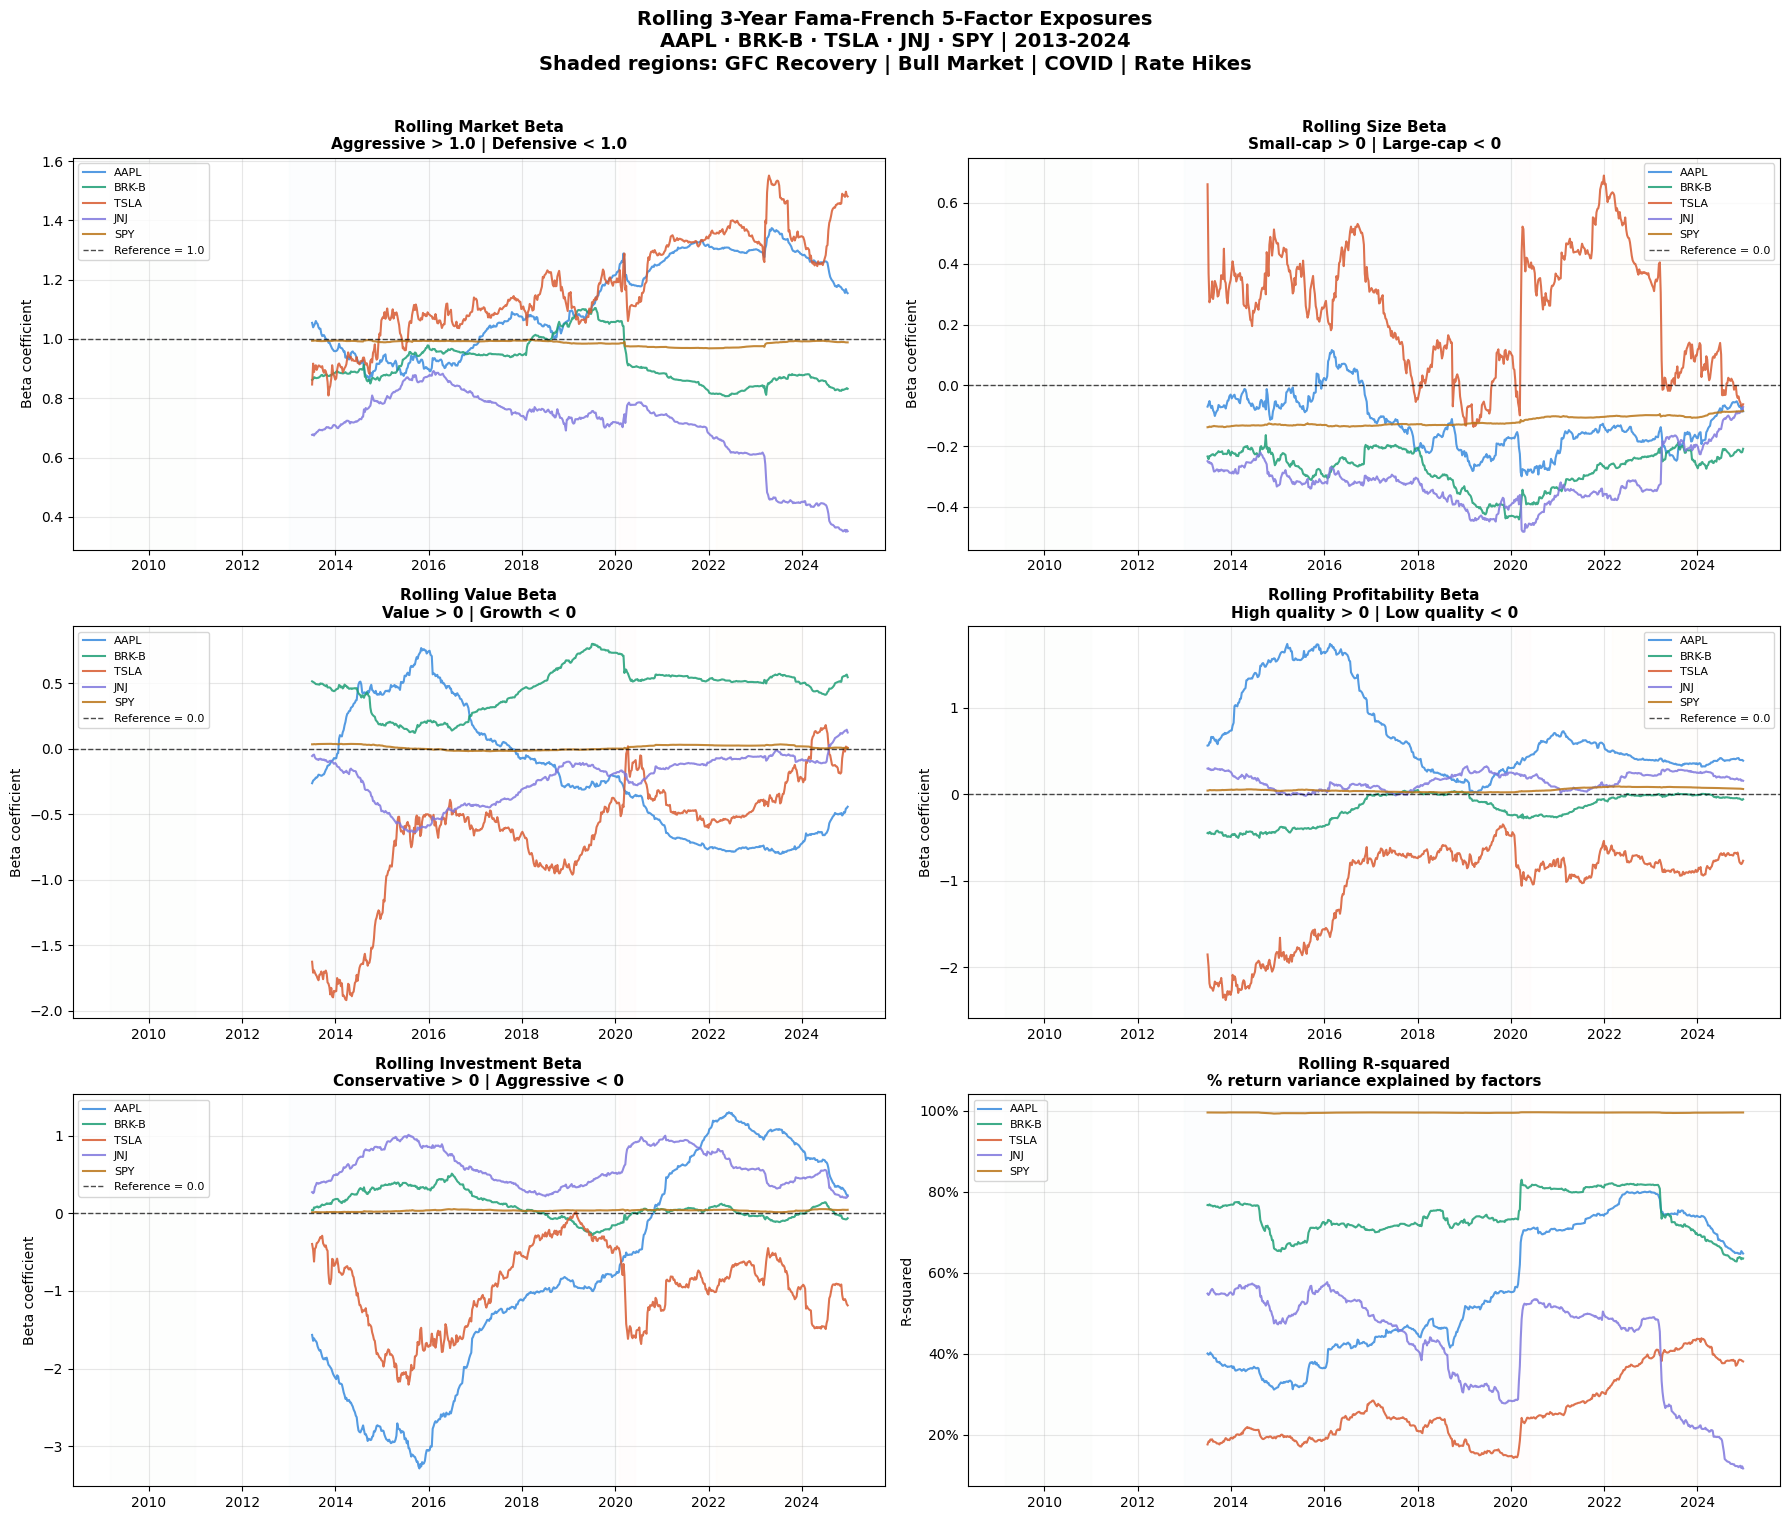

All rolling factors chart saved


In [8]:
# ============================================
# CHART 3 — ALL ROLLING FACTOR BETAS
# 6-panel chart: one per factor
# ============================================
plot_factors = [
    ("Mkt_RF", "Market Beta",
     "Aggressive > 1.0 | Defensive < 1.0", 1.0),
    ("SMB",    "Size Beta",
     "Small-cap > 0 | Large-cap < 0", 0.0),
    ("HML",    "Value Beta",
     "Value > 0 | Growth < 0", 0.0),
    ("RMW",    "Profitability Beta",
     "High quality > 0 | Low quality < 0", 0.0),
    ("CMA",    "Investment Beta",
     "Conservative > 0 | Aggressive < 0", 0.0),
    ("R2",     "R-squared",
     "% return variance explained by factors", None),
]

fig, axes = plt.subplots(
    3, 2, figsize=(18, 15))
axes = axes.flatten()

for ax, (factor, title, subtitle, ref) in zip(
        axes, plot_factors):

    for ticker, df in rolling.items():
        if df.empty or factor not in df.columns:
            continue
        ax.plot(
            df.index, df[factor],
            label=ticker,
            color=colors_map[ticker],
            linewidth=1.5, alpha=0.85
        )

    # Reference line
    if ref is not None:
        ax.axhline(
            ref, color="black",
            linewidth=1, linestyle="--",
            alpha=0.7,
            label=f"Reference = {ref}"
        )

    # Regime shading
    for name, (start, end,
                color, label) in regimes.items():
        try:
            ax.axvspan(
                start, end,
                alpha=0.08, color=color, zorder=0
            )
        except Exception:
            pass

    ax.set_title(
        f"Rolling {title}\n{subtitle}",
        fontweight="bold", fontsize=11
    )
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

    if factor == "R2":
        ax.set_ylabel("R-squared", fontsize=10)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(
                lambda y, _: f"{y:.0%}"))
    else:
        ax.set_ylabel("Beta coefficient", fontsize=10)

plt.suptitle(
    "Rolling 3-Year Fama-French 5-Factor Exposures\n"
    "AAPL · BRK-B · TSLA · JNJ · SPY | 2013-2024\n"
    "Shaded regions: GFC Recovery | Bull Market | "
    "COVID | Rate Hikes",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/rolling_all_factors.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("All rolling factors chart saved")

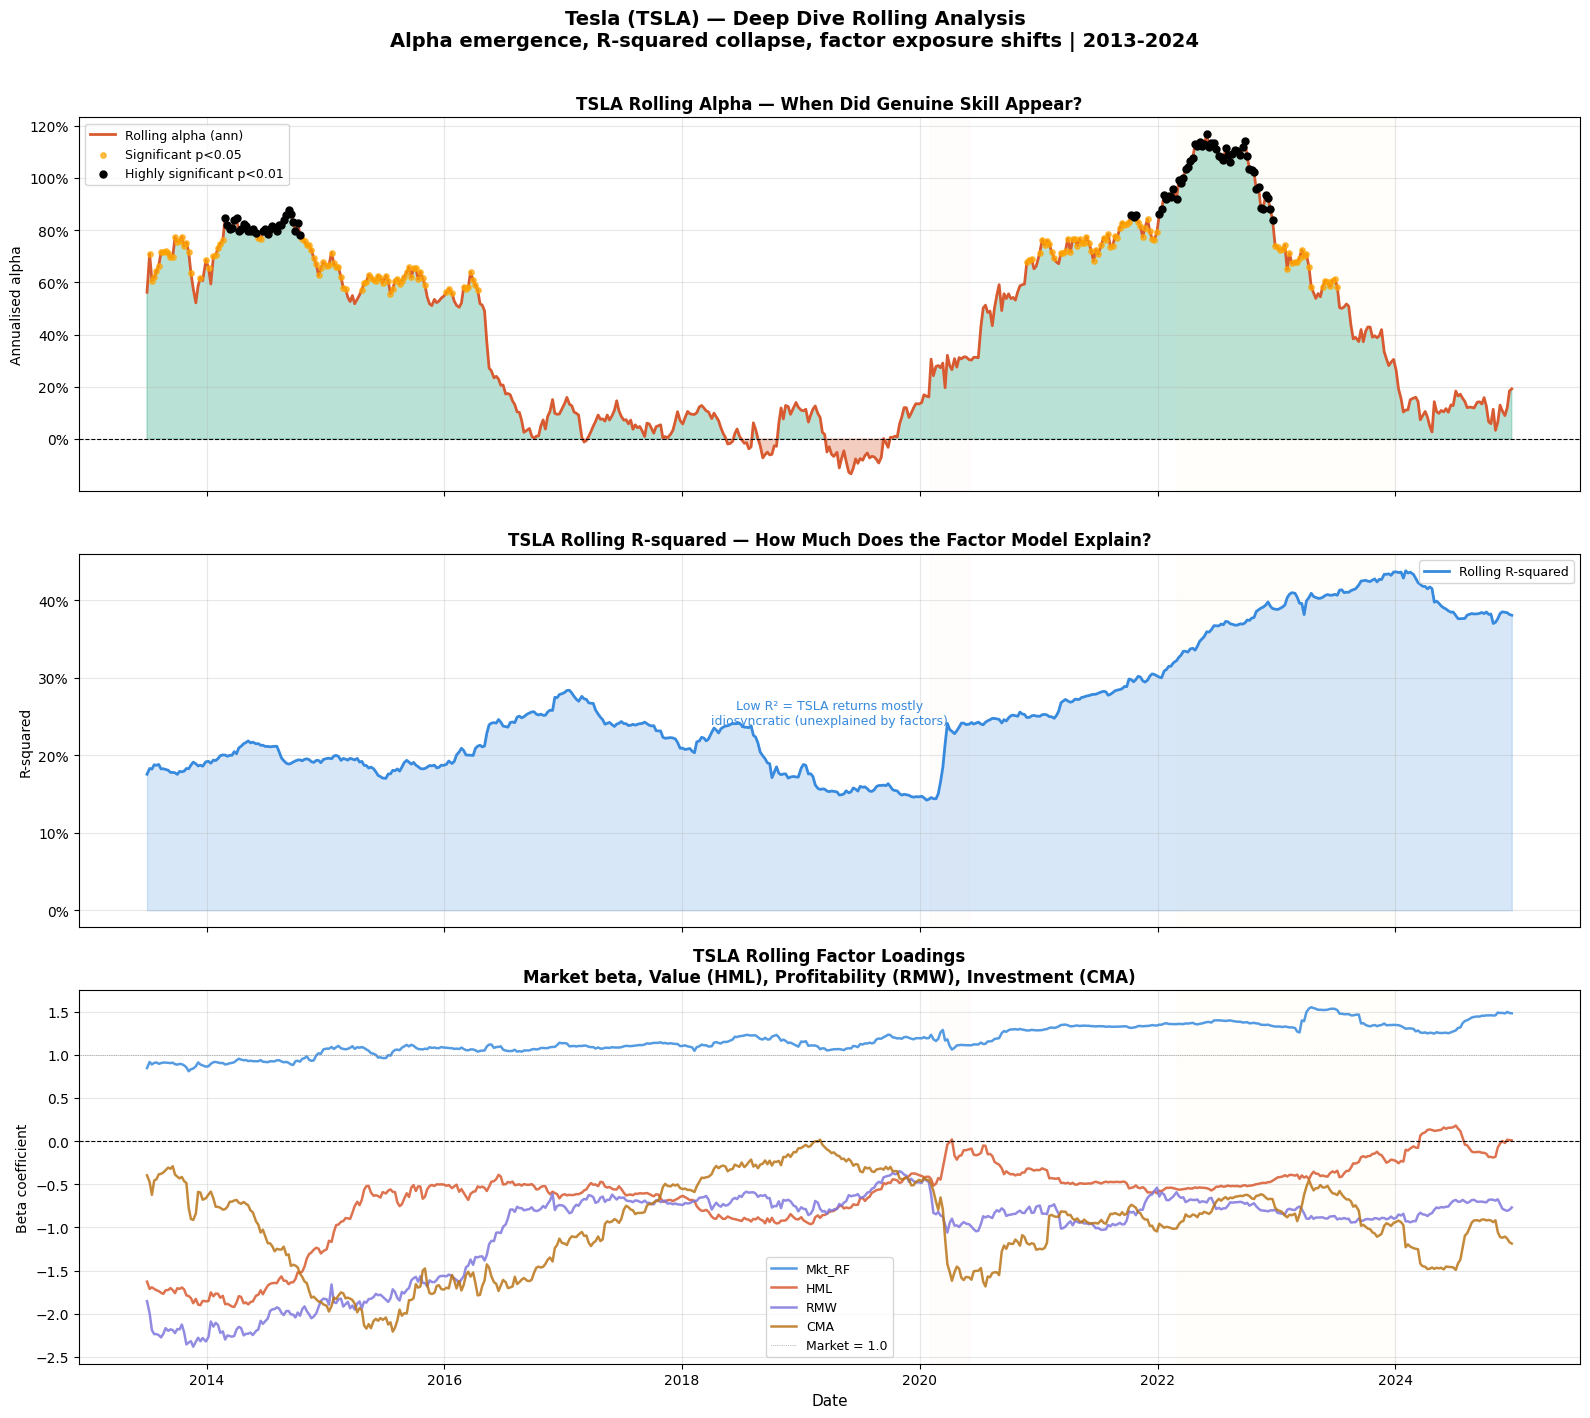

TSLA deep dive chart saved


In [9]:
# ============================================
# CHART 4 — TSLA DEEP DIVE
# TSLA is the most interesting case —
# high alpha, low R², dramatic factor shifts
# ============================================
tsla = rolling.get("TSLA")

if tsla is not None and not tsla.empty:
    fig, axes = plt.subplots(
        3, 1, figsize=(16, 14), sharex=True)

    # Panel 1 — TSLA rolling alpha with price context
    axes[0].plot(
        tsla.index, tsla["Alpha"],
        color="#D85A30", linewidth=2,
        label="Rolling alpha (ann)"
    )
    axes[0].fill_between(
        tsla.index, tsla["Alpha"], 0,
        where=(tsla["Alpha"] > 0),
        alpha=0.3, color="#1D9E75"
    )
    axes[0].fill_between(
        tsla.index, tsla["Alpha"], 0,
        where=(tsla["Alpha"] < 0),
        alpha=0.3, color="#D85A30"
    )

    # Mark significant periods
    sig_95 = tsla["Alpha_pval"] < 0.05
    sig_99 = tsla["Alpha_pval"] < 0.01
    axes[0].scatter(
        tsla.index[sig_95],
        tsla["Alpha"][sig_95],
        color="orange", s=15, zorder=5,
        label="Significant p<0.05", alpha=0.7
    )
    axes[0].scatter(
        tsla.index[sig_99],
        tsla["Alpha"][sig_99],
        color="black", s=25, zorder=6,
        label="Highly significant p<0.01"
    )
    axes[0].axhline(0, color="black",
                    linewidth=0.8, linestyle="--")
    axes[0].set_title(
        "TSLA Rolling Alpha — When Did Genuine "
        "Skill Appear?",
        fontweight="bold", fontsize=12
    )
    axes[0].set_ylabel("Annualised alpha")
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Panel 2 — Rolling R-squared
    axes[1].plot(
        tsla.index, tsla["R2"],
        color="#378ADD", linewidth=2,
        label="Rolling R-squared"
    )
    axes[1].fill_between(
        tsla.index, tsla["R2"],
        alpha=0.2, color="#378ADD"
    )
    axes[1].set_title(
        "TSLA Rolling R-squared — "
        "How Much Does the Factor Model Explain?",
        fontweight="bold", fontsize=12
    )
    axes[1].set_ylabel("R-squared")
    axes[1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].annotate(
        "Low R² = TSLA returns mostly\n"
        "idiosyncratic (unexplained by factors)",
        xy=(tsla.index[len(tsla)//2],
            tsla["R2"].median()),
        fontsize=9, color="#378ADD",
        ha="center"
    )

    # Panel 3 — Key factor loadings
    for factor, color in [
        ("Mkt_RF", "#378ADD"),
        ("HML",    "#D85A30"),
        ("RMW",    "#7F77DD"),
        ("CMA",    "#BA7517")
    ]:
        axes[2].plot(
            tsla.index, tsla[factor],
            label=factor,
            color=color, linewidth=1.8, alpha=0.85
        )
    axes[2].axhline(
        0, color="black",
        linewidth=0.8, linestyle="--")
    axes[2].axhline(
        1, color="grey",
        linewidth=0.5, linestyle=":",
        label="Market = 1.0")
    axes[2].set_title(
        "TSLA Rolling Factor Loadings\n"
        "Market beta, Value (HML), "
        "Profitability (RMW), Investment (CMA)",
        fontweight="bold", fontsize=12
    )
    axes[2].set_ylabel("Beta coefficient")
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.3)
    axes[2].set_xlabel("Date", fontsize=11)

    # Shade COVID and rate hike periods
    for name, (start, end, color, label) in [
        ("COVID", ("2020-02-01", "2020-06-01",
                   "#FFEBEE", "COVID")),
        ("Rates", ("2022-03-01", "2023-12-31",
                   "#FFF8E1", "Rate Hikes"))
    ]:
        for ax in axes:
            try:
                ax.axvspan(
                    start, end,
                    alpha=0.12, color=color, zorder=0)
            except Exception:
                pass

    plt.suptitle(
        "Tesla (TSLA) — Deep Dive Rolling Analysis\n"
        "Alpha emergence, R-squared collapse, "
        "factor exposure shifts | 2013-2024",
        fontsize=14, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig(
        "../reports/figures/tsla_deep_dive.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("TSLA deep dive chart saved")

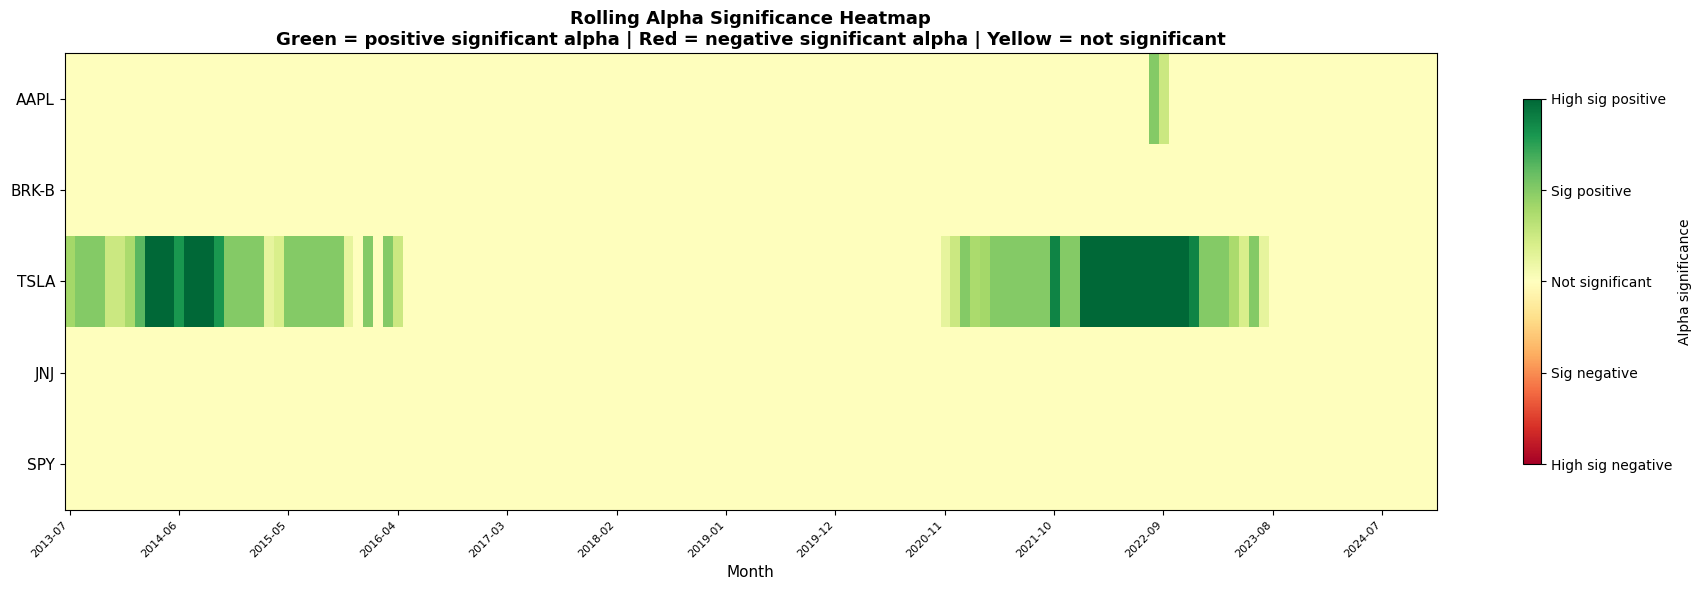

Alpha significance heatmap saved


In [10]:
# ============================================
# CHART 5 — ALPHA SIGNIFICANCE HEATMAP
# Shows across all tickers and time when
# alpha was positive/negative/significant
# ============================================
fig, ax = plt.subplots(figsize=(18, 6))

# Build a unified date index
all_dates = sorted(set(
    date
    for df in rolling.values()
    if not df.empty
    for date in df.index
))

# Create significance matrix
sig_matrix = pd.DataFrame(
    index=all_dates,
    columns=tickers,
    dtype=float
)

for ticker, df in rolling.items():
    if df.empty:
        continue
    for date, row in df.iterrows():
        if date in sig_matrix.index:
            alpha = row["Alpha"]
            pval  = row["Alpha_pval"]
            # Encode: +2 highly sig positive,
            # +1 sig positive, 0 not sig,
            # -1 sig negative, -2 highly sig negative
            if pval < 0.01:
                sig_matrix.loc[date, ticker] = (
                    2 if alpha > 0 else -2)
            elif pval < 0.05:
                sig_matrix.loc[date, ticker] = (
                    1 if alpha > 0 else -1)
            else:
                sig_matrix.loc[date, ticker] = 0

sig_matrix = sig_matrix.dropna(how="all")

# Resample to monthly for readability
sig_monthly = sig_matrix.resample("ME").mean()

im = ax.imshow(
    sig_monthly.T.values,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-2, vmax=2,
    interpolation="nearest"
)

ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers, fontsize=11)

# Monthly x-axis — show every 12 months
n_months = len(sig_monthly)
step_m   = max(1, n_months // 12)
ax.set_xticks(range(0, n_months, step_m))
ax.set_xticklabels(
    [str(d)[:7]
     for d in sig_monthly.index[::step_m]],
    rotation=45, ha="right", fontsize=8
)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Alpha significance", fontsize=10)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.set_ticklabels([
    "High sig negative",
    "Sig negative",
    "Not significant",
    "Sig positive",
    "High sig positive"
])

ax.set_title(
    "Rolling Alpha Significance Heatmap\n"
    "Green = positive significant alpha | "
    "Red = negative significant alpha | "
    "Yellow = not significant",
    fontweight="bold", fontsize=13
)
ax.set_xlabel("Month", fontsize=11)

plt.tight_layout()
plt.savefig(
    "../reports/figures/alpha_heatmap.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Alpha significance heatmap saved")

In [12]:
# ============================================
# SAVE ROLLING RESULTS AND PRINT SUMMARY
# ============================================
import os

for ticker, df in rolling.items():
    if not df.empty:
        df.to_csv(
            f"../data/processed/"
            f"rolling_{ticker.replace('-','_')}.csv"
        )

print("=" * 60)
print("   COMPLETE — ROLLING REGRESSION SUMMARY")
print("=" * 60)
print(f"\n  Window:     756 trading days (3 years)")
print(f"  Step:       5 days (weekly resolution)")
print(f"  Charts:     5 saved to reports/figures/")

print(f"\n  Rolling alpha insights:")
for ticker, df in rolling.items():
    if df.empty:
        continue
    pct_pos = (df["Alpha"] > 0).mean() * 100
    pct_sig = (df["Alpha_pval"] < 0.05).mean() * 100
    peak    = df["Alpha"].max()
    trough  = df["Alpha"].min()
    print(f"\n  {ticker}:")
    print(f"    {pct_pos:.0f}% of windows: positive alpha")
    print(f"    {pct_sig:.0f}% of windows: "
          f"statistically significant (p<0.05)")
    print(f"    Peak alpha:   {peak:.2%}")
    print(f"    Trough alpha: {trough:.2%}")

print("\n" + "=" * 60)

   COMPLETE — ROLLING REGRESSION SUMMARY

  Window:     756 trading days (3 years)
  Step:       5 days (weekly resolution)
  Charts:     5 saved to reports/figures/

  Rolling alpha insights:

  AAPL:
    93% of windows: positive alpha
    1% of windows: statistically significant (p<0.05)
    Peak alpha:   22.22%
    Trough alpha: -6.44%

  BRK-B:
    84% of windows: positive alpha
    0% of windows: statistically significant (p<0.05)
    Peak alpha:   7.72%
    Trough alpha: -3.09%

  TSLA:
    92% of windows: positive alpha
    42% of windows: statistically significant (p<0.05)
    Peak alpha:   116.68%
    Trough alpha: -13.35%

  JNJ:
    56% of windows: positive alpha
    0% of windows: statistically significant (p<0.05)
    Peak alpha:   9.30%
    Trough alpha: -10.46%

  SPY:
    27% of windows: positive alpha
    0% of windows: statistically significant (p<0.05)
    Peak alpha:   0.42%
    Trough alpha: -0.88%

